In [22]:
# 160 fitur
#     ↓ STEP 1: Hapus administratif/survey (manual)
#     ↓ STEP 2: Hapus missing >= 30% (otomatis)
#     ↓ STEP 3: Pilih fitur berdasarkan domain knowledge (paper)
#     ↓ STEP 4: Hapus kode ambigu → NaN
#     ↓ STEP 5: Hapus baris null
#     ↓ STEP 6: Hapus multikolinear (Pearson > 0.85)
#     ↓ STEP 7: RFECV
#     ↓
# fitur final

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
# =============================================================
# STEP 1: LOAD DATA
# =============================================================
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/percobaancvd/datasetfix/heart_disease_new_dataset1.csv')
print(f"Shape awal: {data.shape}")
print(data['CVD_LABEL'].value_counts())

Shape awal: (438693, 304)
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64


In [24]:
# =============================================================
# STEP 2: HAPUS KOLOM ADMINISTRATIF/SURVEY (tidak relevan)
# =============================================================
admin_cols = [
    # Identitas & waktu survei
    'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'FMONTH',
    'DISPCODE', 'SEQNO', '_PSU', '_STATE',
    # Cell phone survey
    'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1',
    'PVTRESD3', 'CSTATE1', 'LANDLINE', 'HHADULT',
    # Weighting variables
    '_LLCPWT2', '_LLCPWT', '_STSTR', '_STRWT',
    '_RAWRAKE', '_WT2RAKE', '_DUALUSE',
    # Buah & sayur raw (sudah ada calculated)
    # '_VEGRES1', '_FRTRES1', '_MISVEG1', '_MISFRT1',
]
admin_exist = [c for c in admin_cols if c in data.columns]
data = data.drop(columns=admin_exist)
print(f"\nStep 2 — Hapus admin ({len(admin_exist)}): {data.shape}")

# =============================================================
# STEP 3: HAPUS MISSING >= 30%
# =============================================================
miss = data.isnull().mean() * 100
cols_high_miss = miss[miss >= 30].index.tolist()
data = data.drop(columns=cols_high_miss)
print(f"Step 3 — Hapus missing >=30% ({len(cols_high_miss)}): {data.shape}")


Step 2 — Hapus admin (24): (438693, 280)
Step 3 — Hapus missing >=30% (155): (438693, 125)


In [25]:
severity_map = {
    'Healt'            : 0,  # Sehat
    'Stroke Only'       : 1,  # Level 1 → 1 kondisi
    'CHD Only'          : 1,  # Level 1 → 1 kondisi
    'Heart Attack Only' : 1,  # Level 1 → 1 kondisi
    'MI + CHD'          : 1,  # Level 2 → 2 kondisi
    'MI + Stroke'       : 1,  # Level 2 → 2 kondisi
    'CHD + Stroke'      : 1,  # Level 2 → 2 kondisi
    'All Three'         : 1,  # Level 3 → 3 kondisi
}

data['CVD_SEVERITY'] = data['CVD_LABEL'].map(severity_map)

# Verifikasi
print(data['CVD_SEVERITY'].value_counts())
print(f"\nTotal : {len(data):,}")

CVD_SEVERITY
0    391852
1     46841
Name: count, dtype: int64

Total : 438,693


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Columns: 126 entries, CELLSEX to CVD_SEVERITY
dtypes: float64(124), int64(1), object(1)
memory usage: 421.7+ MB


In [27]:
data = data.drop(columns=['_VEGRES1','_FRTRES1','_MISVEG1','_MISFRT1','CVD_LABEL'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Columns: 121 entries, CELLSEX to CVD_SEVERITY
dtypes: float64(120), int64(1)
memory usage: 405.0 MB


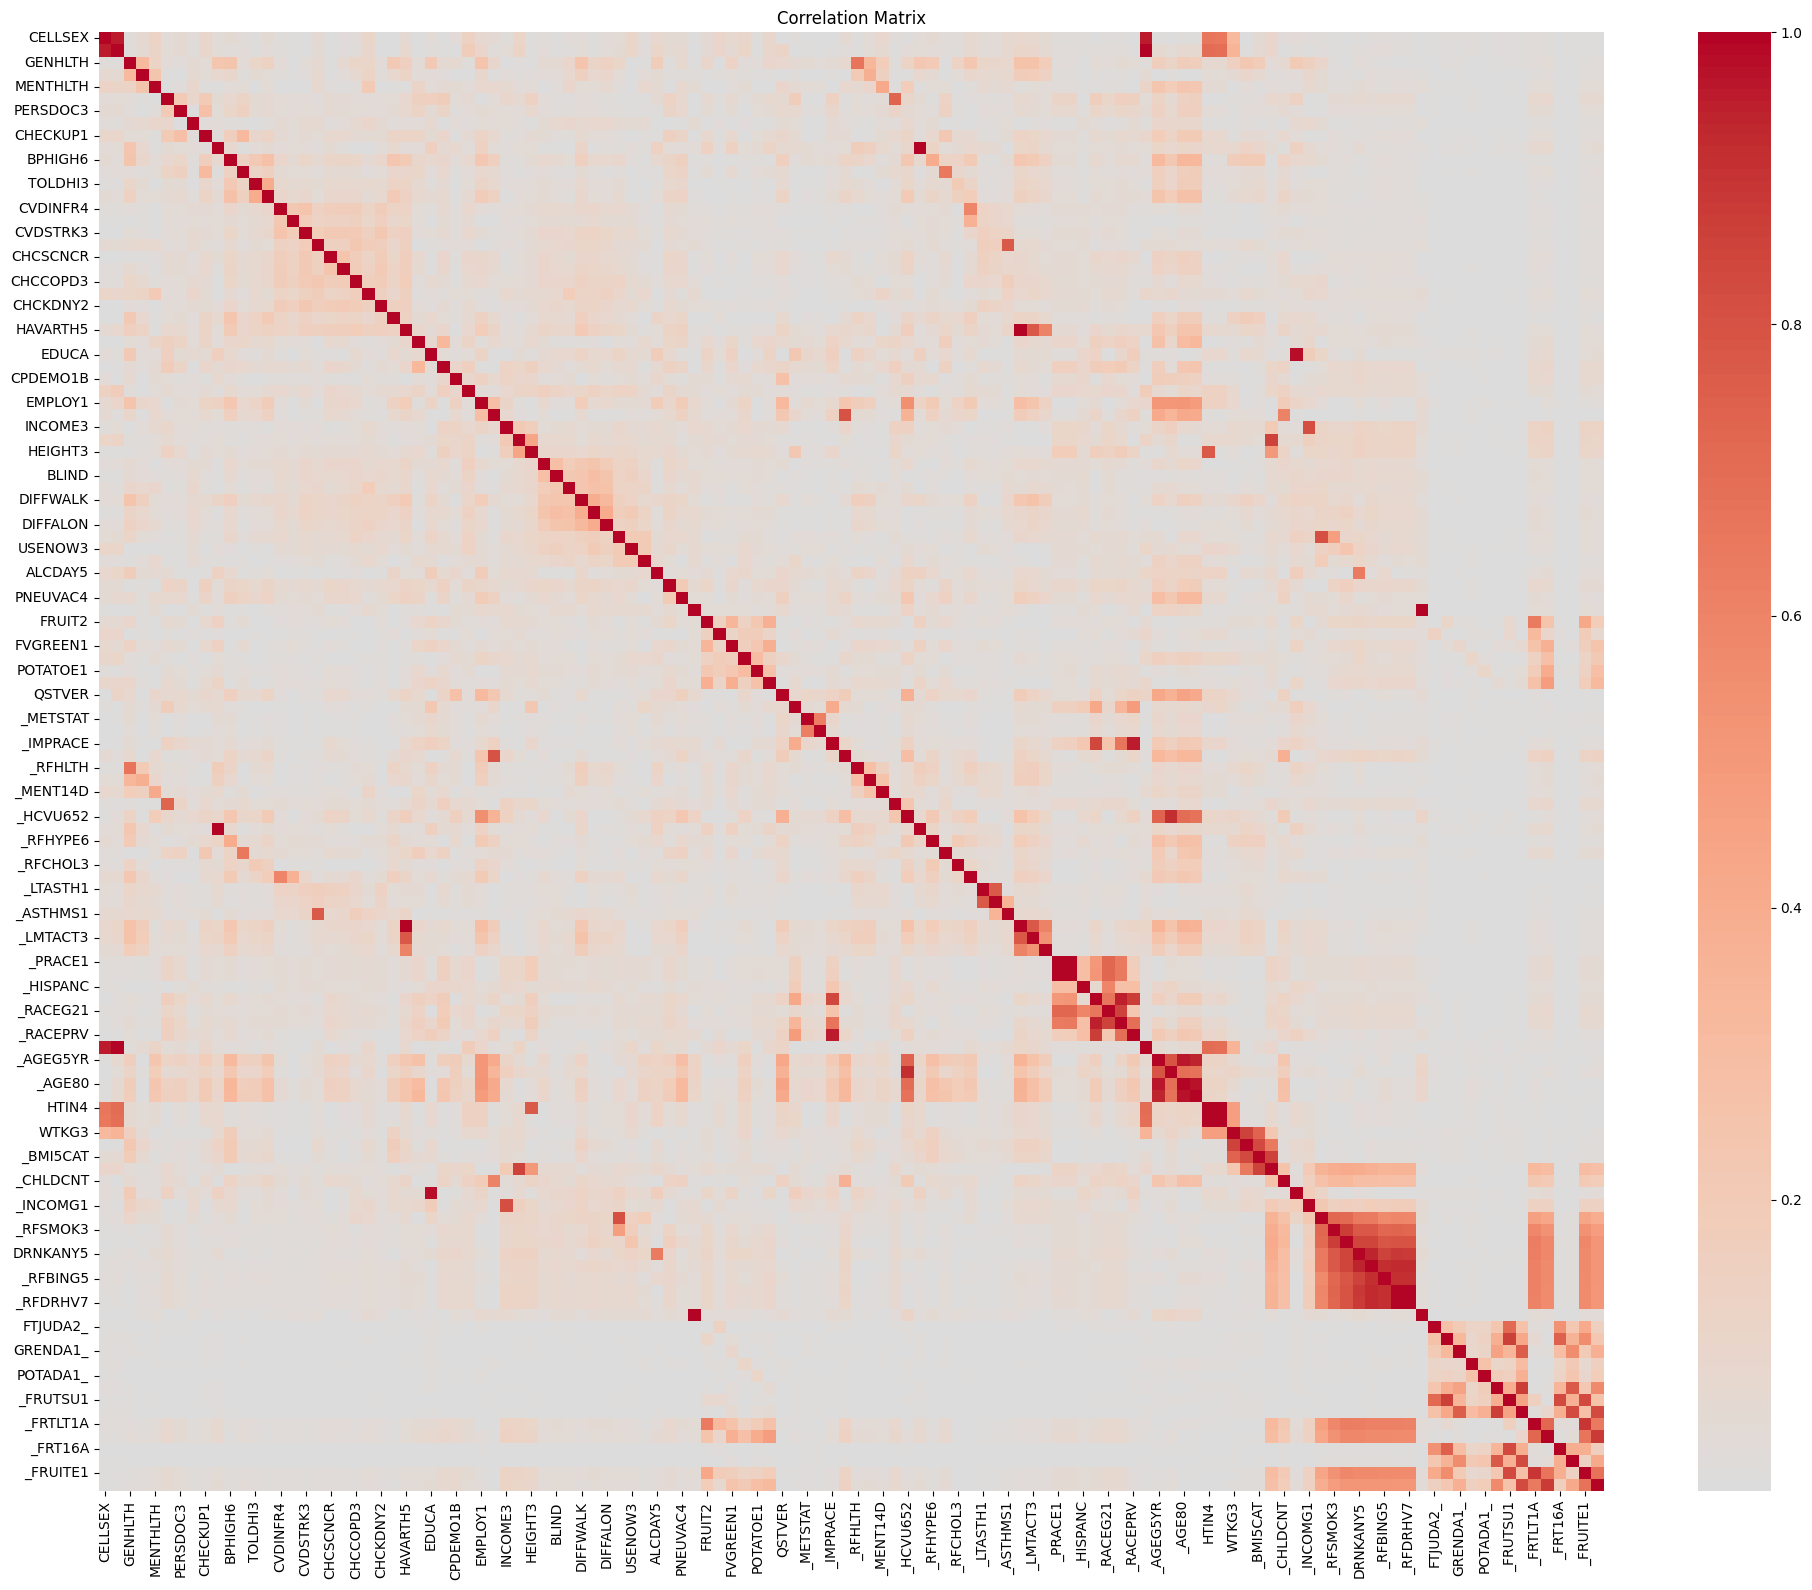

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi
corr_matrix = data.select_dtypes(include='float64').corr().abs()

# Visualisasi heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm',
            center=0,
            annot=False,  # ganti True kalau mau lihat angkanya (lambat kalau banyak fitur)
            fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [29]:
# Tampilkan pasangan fitur dengan korelasi > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.80]

high_corr_df = pd.DataFrame(high_corr, columns=['Fitur_1', 'Fitur_2', 'Korelasi'])
high_corr_df = high_corr_df.sort_values('Korelasi', ascending=False)

print(f"Pasangan fitur dengan korelasi > 0.85: {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Pasangan fitur dengan korelasi > 0.85: 46
 Fitur_1  Fitur_2  Korelasi
_DRDXAR3 HAVARTH5  1.000000
    HTM4    HTIN4  0.999627
 _MRACE1  _PRACE1  0.999029
    _SEX   SEXVAR  0.997810
_RFDRHV7 _DRNKWK1  0.996025
_AIDTST4  HIVTST7  0.993446
_TOTINDA EXERANY2  0.992476
 _EDUCAG    EDUCA  0.979121
  _AGE_G   _AGE80  0.973881
  _AGE80 _AGEG5YR  0.961100
_RACEPRV _IMPRACE  0.960878
  SEXVAR  CELLSEX  0.957192
    _SEX  CELLSEX  0.955145
_RACEGR3    _RACE  0.951210
DROCDY3_ DRNKANY5  0.940350
  _AGE_G _AGEG5YR  0.939260
_DRNKWK1 DROCDY3_  0.928625
_RFDRHV7 DROCDY3_  0.928422
_RFBING5 DROCDY3_  0.920074
_AGE65YR _HCVU652  0.914799
_RFDRHV7 _RFBING5  0.912864
_DRNKWK1 _RFBING5  0.910840
_FRUITE1 _FRTLT1A  0.893178
_DRNKWK1 DRNKANY5  0.884059
_VEGETE1 _VEGLT1A  0.882605
_RFDRHV7 DRNKANY5  0.875737
_VEGESU1 VEGEDA2_  0.873527
_CURECI1 _RFSMOK3  0.873298
_RACEPRV    _RACE  0.871544
_FRUTSU1 FRUTDA2_  0.864627
   _BMI5    WTKG3  0.858912
_RFBING5 DRNKANY5  0.857365
 _RFBMI5  WEIGHT2  0.854933
 _RFBM

In [30]:
# data_drop = ['HAVARTH5','HTIN4','_MRACE1','SEXVAR','HIVTST7','_DRNKWK1','EXERANY2','EDUCA','_AGE_G','_AGE80','_RACEPRV','_IMPRACE','_RACEGR3','CELLSEX','_RACEGR3','_DRNKWK1','DROCDY3_','_AGE65YR','_AGEG5YR','DROCDY3_','_RFBING5','_FRUITE','_DRNKWK1','DRNKANY5','_IMPRACE','_CHISPNC','CHILDREN','_INCOMG1','_RFSMOK3','_AGE65YR']

In [31]:
# Hapus duplikat dari list dulu
data_drop = list(set([
    'HAVARTH5', 'HTIN4', '_MRACE1', 'SEXVAR', 'HIVTST7',
    '_DRNKWK1', 'EXERANY2', 'EDUCA', '_AGE_G', '_AGE80',
    '_RACEPRV', '_IMPRACE', '_RACEGR3', 'CELLSEX', 'DROCDY3_',
    '_AGE65YR', '_AGEG5YR', '_RFBING5', '_FRUITE', 'DRNKANY5',
    '_CHISPNC', 'CHILDREN', '_INCOMG1', '_RFSMOK3',
]))

# Hapus hanya yang ada
cols_exist     = [c for c in data_drop if c in data.columns]
cols_not_found = [c for c in data_drop if c not in data.columns]

data = data.drop(columns=cols_exist)

print(f"✅ Berhasil dihapus ({len(cols_exist)})  : {cols_exist}")
print(f"❌ Tidak ditemukan ({len(cols_not_found)}) : {cols_not_found}")
print(f"\nShape setelah hapus: {data.shape}")
print(f"Fitur tersisa: {data.columns.tolist()}")

✅ Berhasil dihapus (23)  : ['_RFBING5', 'EXERANY2', 'DRNKANY5', '_RFSMOK3', '_AGE80', '_MRACE1', 'HTIN4', '_AGE65YR', '_AGEG5YR', '_CHISPNC', 'CELLSEX', 'DROCDY3_', '_RACEPRV', '_RACEGR3', 'CHILDREN', 'EDUCA', 'SEXVAR', '_IMPRACE', '_DRNKWK1', 'HIVTST7', 'HAVARTH5', '_INCOMG1', '_AGE_G']
❌ Tidak ditemukan (1) : ['_FRUITE']

Shape setelah hapus: (438693, 98)
Fitur tersisa: ['GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'PRIMINSR', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'BPHIGH6', 'CHOLCHK3', 'TOLDHI3', 'CHOLMED3', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'DIABETE4', 'MARITAL', 'RENTHOM1', 'CPDEMO1B', 'VETERAN3', 'EMPLOY1', 'INCOME3', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'USENOW3', 'ECIGNOW1', 'ALCDAY5', 'FLUSHOT7', 'PNEUVAC4', 'FRUIT2', 'FRUITJU2', 'FVGREEN1', 'FRENCHF1', 'POTATOE1', 'VEGETAB2', 'QSTVER', 'QSTLANG', '_METSTAT', '_URBSTAT', '_RFHLTH', '_PHYS14D', '_MENT14D', '_

In [32]:
data.isna().sum()

GENHLTH         4
PHYSHLTH        3
MENTHLTH        2
PRIMINSR        3
PERSDOC3        2
               ..
_FRT16A         0
_VEG23A         0
_FRUITE1        0
_VEGETE1        0
CVD_SEVERITY    0
Length: 98, dtype: int64

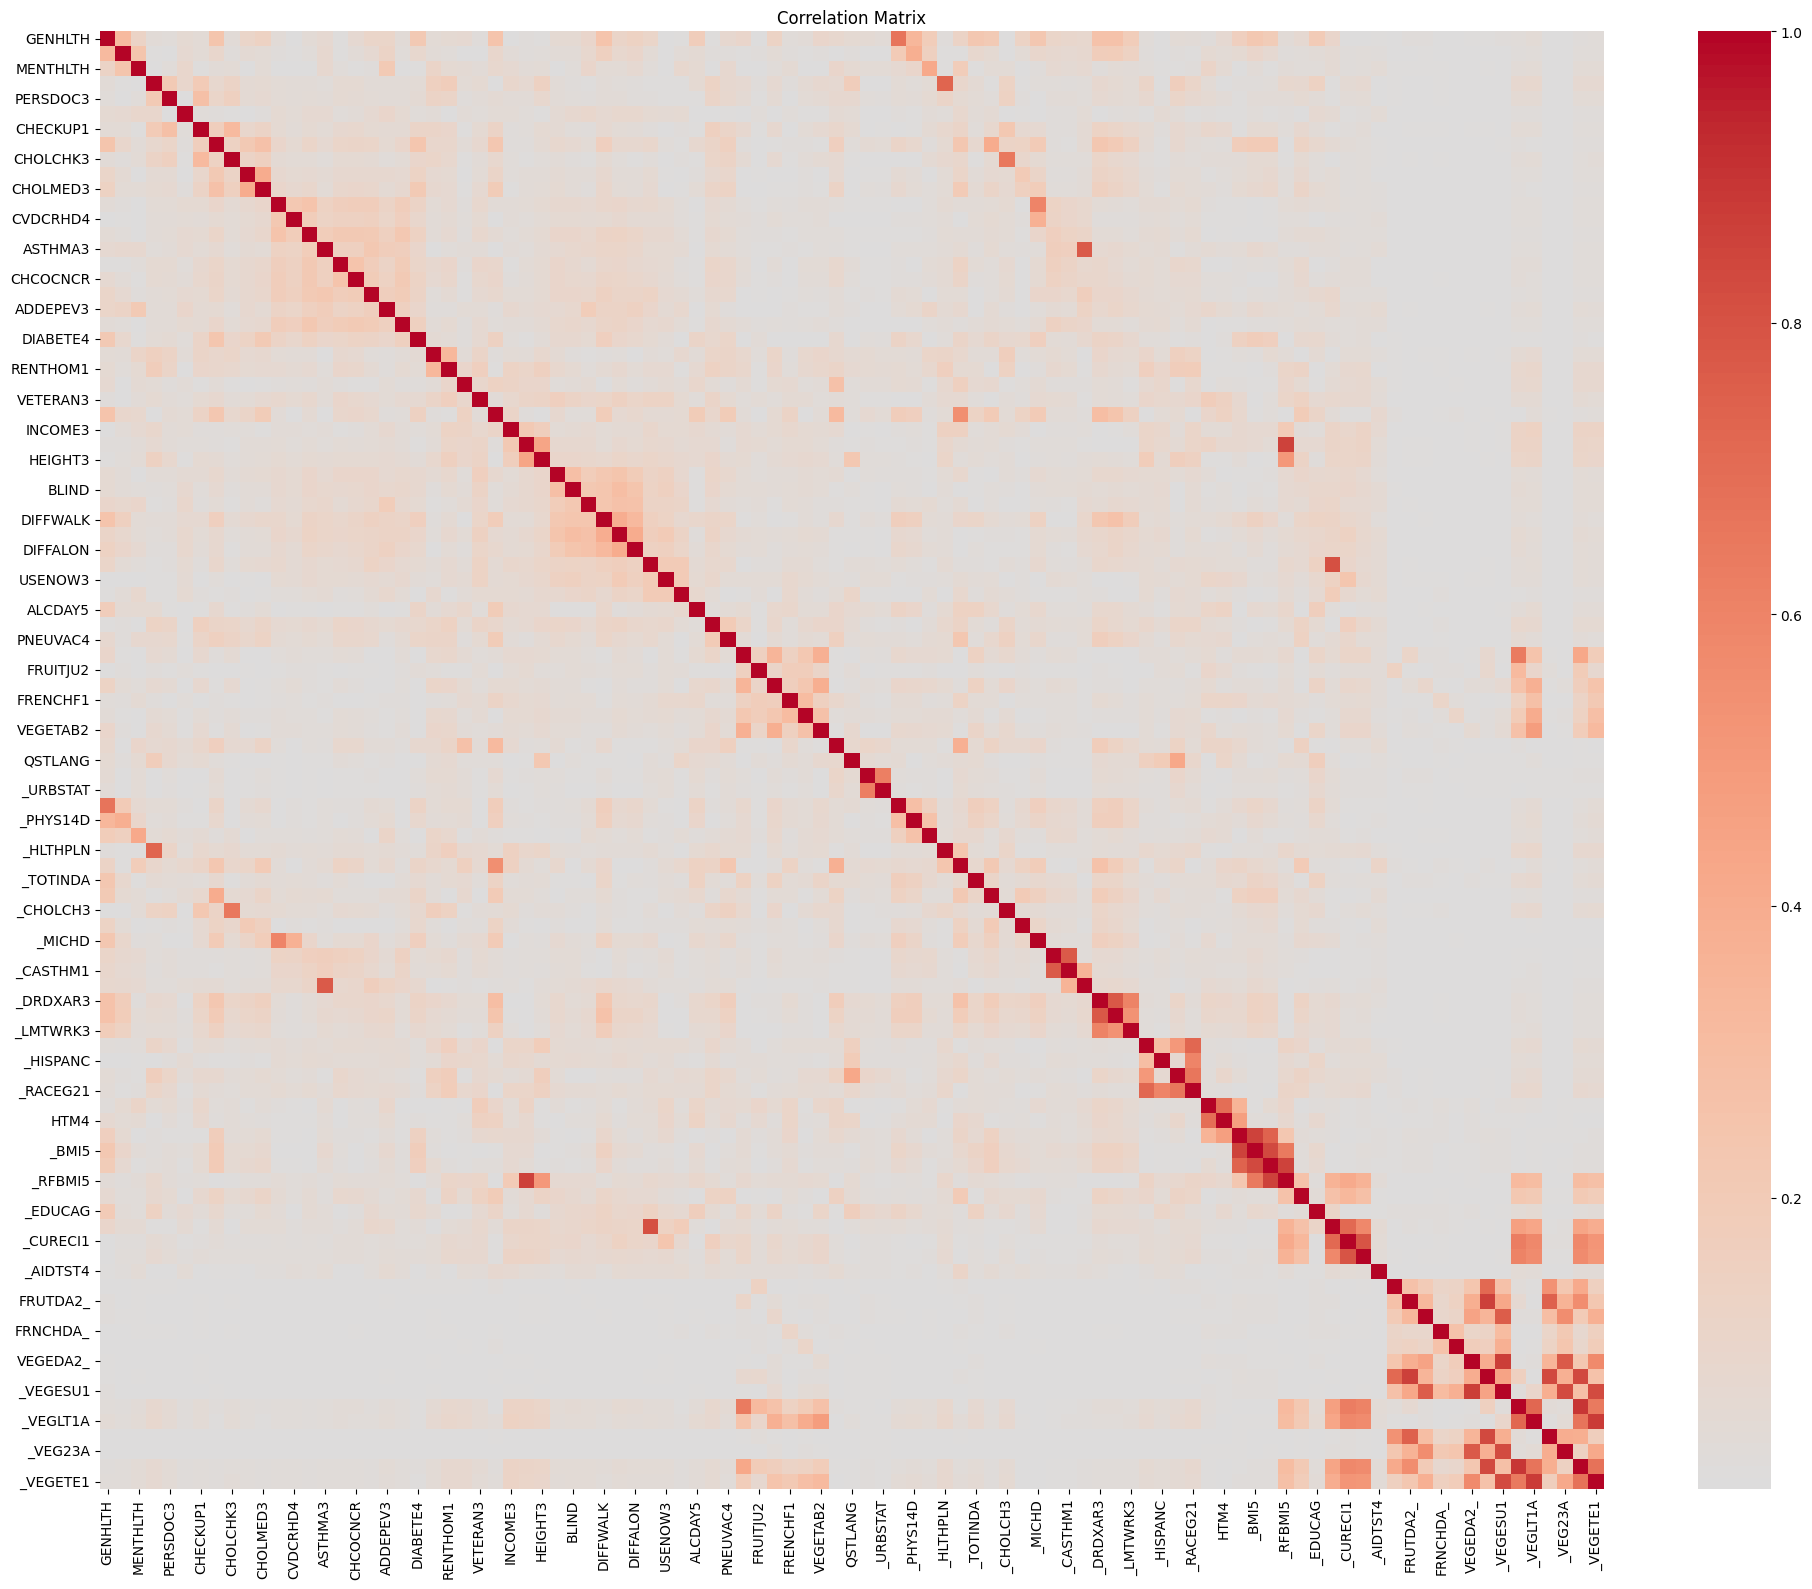

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi
corr_matrix = data.select_dtypes(include='float64').corr().abs()

# Visualisasi heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm',
            center=0,
            annot=False,  # ganti True kalau mau lihat angkanya (lambat kalau banyak fitur)
            fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [34]:
# Tampilkan pasangan fitur dengan korelasi > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.80]

high_corr_df = pd.DataFrame(high_corr, columns=['Fitur_1', 'Fitur_2', 'Korelasi'])
high_corr_df = high_corr_df.sort_values('Korelasi', ascending=False)

print(f"Pasangan fitur dengan korelasi > 0.85: {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Pasangan fitur dengan korelasi > 0.85: 13
 Fitur_1  Fitur_2  Korelasi
_FRUITE1 _FRTLT1A  0.893178
_VEGETE1 _VEGLT1A  0.882605
_VEGESU1 VEGEDA2_  0.873527
_FRUTSU1 FRUTDA2_  0.864627
   _BMI5    WTKG3  0.858912
 _RFBMI5  WEIGHT2  0.854933
 _RFBMI5 _BMI5CAT  0.854379
_BMI5CAT    _BMI5  0.830420
 _FRT16A _FRUTSU1  0.830286
_FRUITE1 _FRUTSU1  0.830286
_VEGETE1 _VEGESU1  0.827597
 _VEG23A _VEGESU1  0.827597
_SMOKER3 SMOKE100  0.810600


In [35]:
# Hapus duplikat dari list dulu
data_drop = list(set(['_FRUITE1','_VEGETE1','_VEGESU1','VEGEDA2_','WTKG3','_RFBMI5','WEIGHT2','_BMI5CAT','_SMOKER3','_FRUTSU1','_FRUTSU1','_FRT16A','FRUTDA2_']))

# Hapus hanya yang ada
cols_exist     = [c for c in data_drop if c in data.columns]
cols_not_found = [c for c in data_drop if c not in data.columns]

data = data.drop(columns=cols_exist)

print(f"✅ Berhasil dihapus ({len(cols_exist)})  : {cols_exist}")
print(f"❌ Tidak ditemukan ({len(cols_not_found)}) : {cols_not_found}")
print(f"\nShape setelah hapus: {data.shape}")
print(f"Fitur tersisa: {data.columns.tolist()}")

✅ Berhasil dihapus (12)  : ['WTKG3', 'FRUTDA2_', '_BMI5CAT', '_FRUTSU1', '_FRUITE1', '_RFBMI5', '_SMOKER3', 'VEGEDA2_', 'WEIGHT2', '_VEGESU1', '_FRT16A', '_VEGETE1']
❌ Tidak ditemukan (0) : []

Shape setelah hapus: (438693, 86)
Fitur tersisa: ['GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'PRIMINSR', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'BPHIGH6', 'CHOLCHK3', 'TOLDHI3', 'CHOLMED3', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'DIABETE4', 'MARITAL', 'RENTHOM1', 'CPDEMO1B', 'VETERAN3', 'EMPLOY1', 'INCOME3', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'USENOW3', 'ECIGNOW1', 'ALCDAY5', 'FLUSHOT7', 'PNEUVAC4', 'FRUIT2', 'FRUITJU2', 'FVGREEN1', 'FRENCHF1', 'POTATOE1', 'VEGETAB2', 'QSTVER', 'QSTLANG', '_METSTAT', '_URBSTAT', '_RFHLTH', '_PHYS14D', '_MENT14D', '_HLTHPLN', '_HCVU652', '_TOTINDA', '_RFHYPE6', '_CHOLCH3', '_RFCHOL3', '_MICHD', '_LTASTH1', '_CASTHM1', '_ASTHMS1', '_DRDXAR3', '_LMTACT3', '_L


Kolom dengan sisa null: 61 dari 86 fitur
          null_count  null_percent    dtype
CHOLMED3       61571         14.04  float64
_RFCHOL3       61151         13.94  float64
TOLDHI3        60836         13.87  float64
POTADA1_       48440         11.04  float64
_BMI5          46852         10.68  float64
FRNCHDA_       44765         10.20  float64
FTJUDA2_       44349         10.11  float64
GRENDA1_       44250         10.09  float64
VEGETAB2       40615          9.26  float64
POTATOE1       39306          8.96  float64
FRENCHF1       38111          8.69  float64
FVGREEN1       36995          8.43  float64
FRUITJU2       35762          8.15  float64
FRUIT2         34175          7.79  float64
_AIDTST4       30151          6.87  float64
PNEUVAC4       29087          6.63  float64
FLUSHOT7       27648          6.30  float64
HTM4           24562          5.60  float64
ALCDAY5        24487          5.58  float64
ECIGNOW1       23025          5.25  float64
USENOW3        21989          5.01

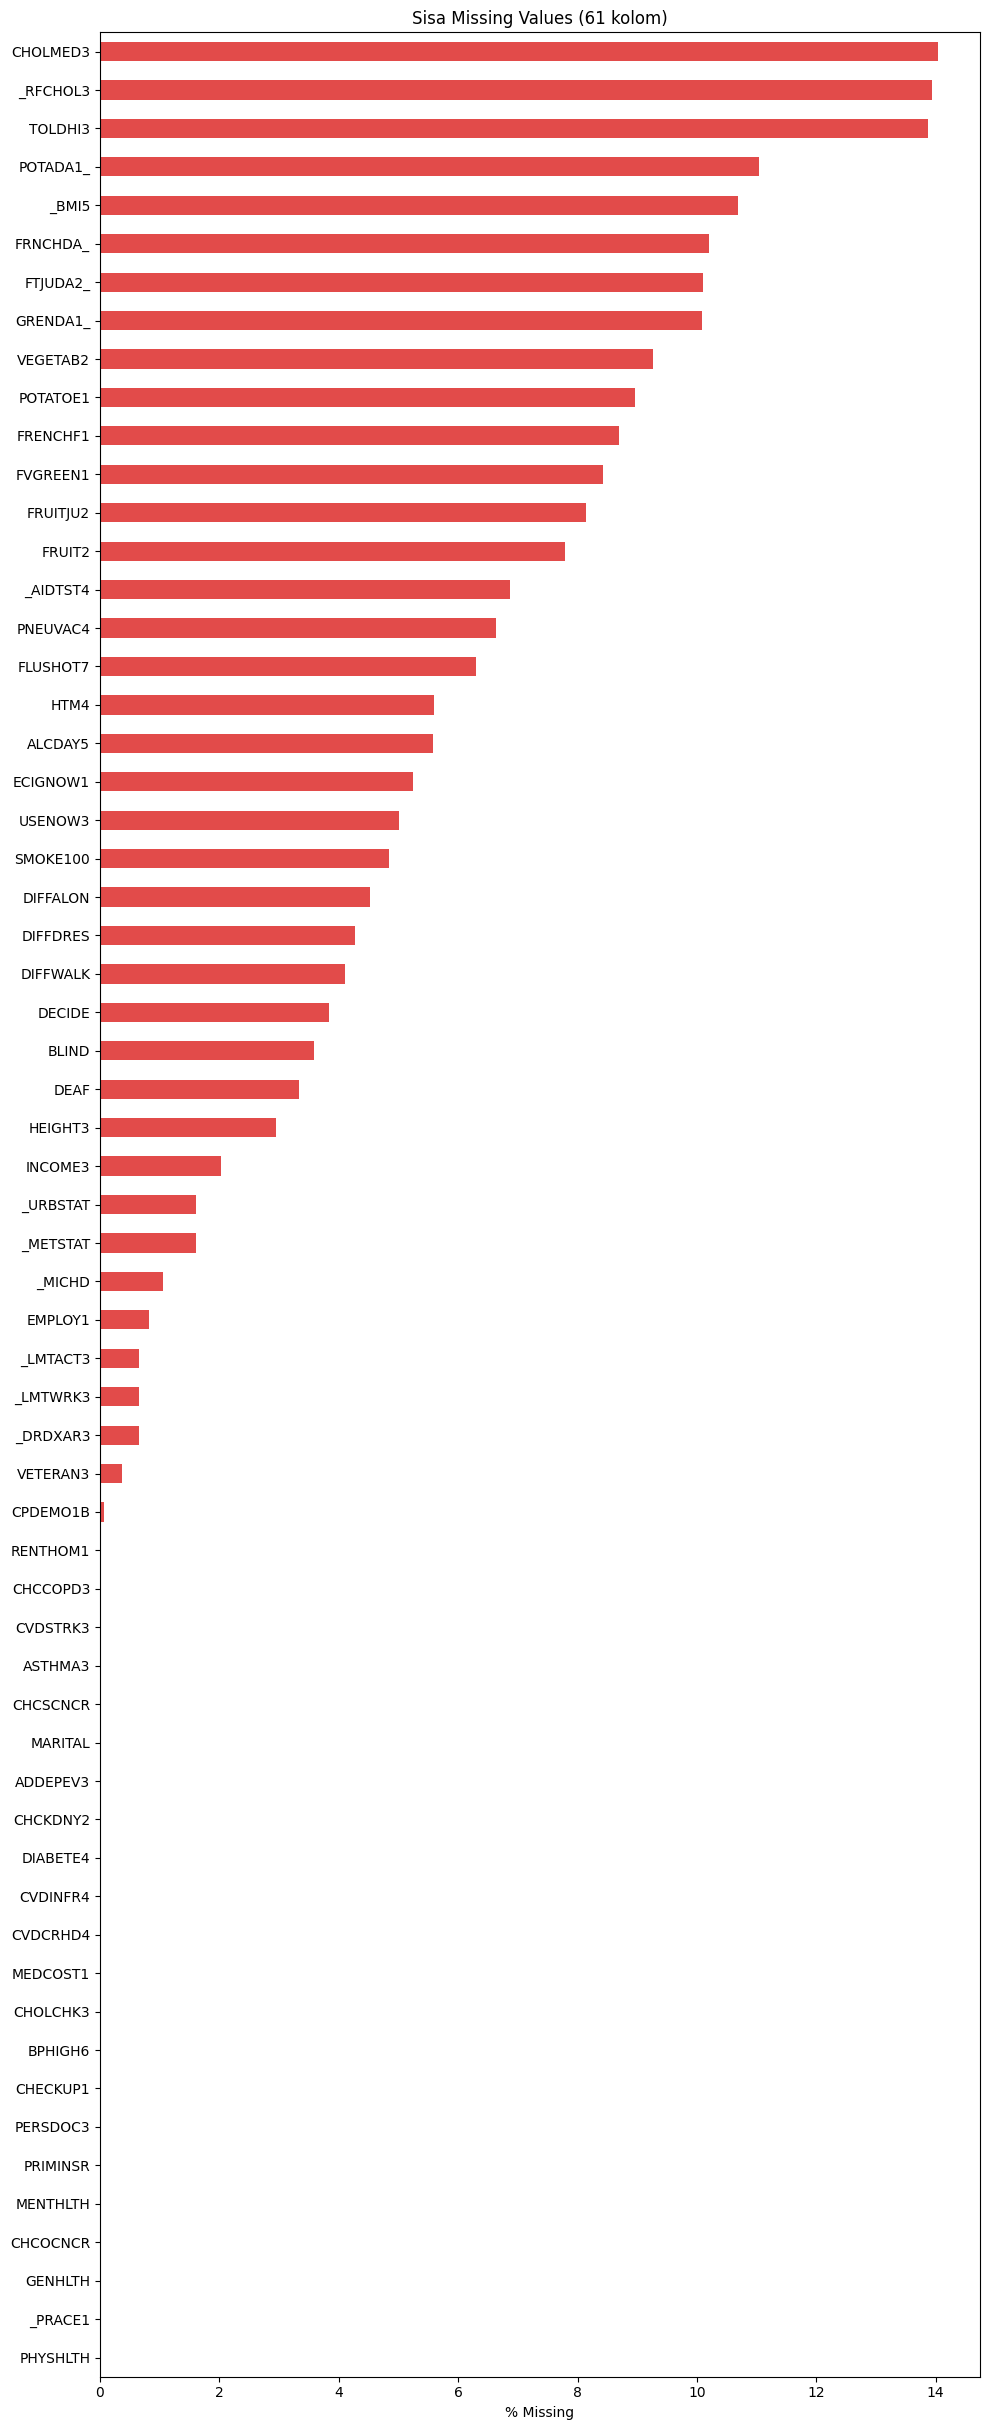

In [39]:
# =============================================================
# 4. CEK SISA MISSING VALUES
# =============================================================
null_summary = pd.DataFrame({
    'null_count':   data.isnull().sum(),
    'null_percent': (data.isnull().sum() / len(data) * 100).round(2),
    'dtype':        data.dtypes
}).sort_values('null_percent', ascending=False)

has_null = null_summary[null_summary['null_count'] > 0]
print(f"\nKolom dengan sisa null: {len(has_null)} dari {len(data.columns)} fitur")

if len(has_null) > 0:
    print(has_null.to_string())

    # Visualisasi
    fig, ax = plt.subplots(figsize=(10, max(4, len(has_null) * 0.4)))
    has_null['null_percent'].sort_values().plot(
        kind='barh', ax=ax, color='#E24B4A'
    )
    ax.set_xlabel('% Missing')
    ax.set_title(f'Sisa Missing Values ({len(has_null)} kolom)')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada missing values tersisa.")

In [ ]:
## hapus dari nilai null
listdata = ['GRENDA1_','_LMTACT3','USENOW3','']

In [37]:
jncdjksbcjkds

NameError: name 'jncdjksbcjkds' is not defined

In [ ]:
data_new = data.dropna()
print(f"Sebelum : {len(data)} baris")
print(f"Sesudah : {len(data_new)} baris")
print(f"Terhapus: {len(data) - len(data_new)} baris")

Sebelum : 438693 baris
Sesudah : 295704 baris
Terhapus: 142989 baris


In [ ]:
# Pastikan semua kolom ini tidak ada
forbidden = ['_MICHD', 'CVDSTRK3', 'CVDCRHD4', 'CVDINFR4']
data_new = data_new.drop(columns=forbidden)
for col in forbidden:
    if col in data_new.columns:
        print(f"⚠️  MASIH ADA: {col}")
    else:
        print(f"✅ Sudah dihapus: {col}")

✅ Sudah dihapus: _MICHD
✅ Sudah dihapus: CVDSTRK3
✅ Sudah dihapus: CVDCRHD4
✅ Sudah dihapus: CVDINFR4


In [ ]:
X = data_new.drop(columns=['CVD_SEVERITY'])
y = data_new['CVD_SEVERITY']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# ── 1. CEK kolom yang bermasalah ──────────────────────────────────────────────
print(X.dtypes)
print("\nKolom non-numerik:", X.select_dtypes(include=['object', 'category']).columns.tolist())

GENHLTH     float64
PHYSHLTH    float64
MENTHLTH    float64
PRIMINSR    float64
PERSDOC3    float64
             ...   
_VEGLT1A    float64
_FRT16A     float64
_VEG23A     float64
_FRUITE1    float64
_VEGETE1    float64
Length: 93, dtype: object

Kolom non-numerik: []


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Pilih salah satu scaler sesuai kebutuhan
# 2. MinMaxScaler - range [0,1] (cocok untuk data tanpa outlier)
scaler = MinMaxScaler()
# Fit pada train, transform pada train & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # ⚠️ Hanya transform, bukan fit_transform!

Class distribution → Sehat: 205446, CVD: 27318
scale_pos_weight   : 7.5205

     PERFORMANCE MEASURES (Binary Classification)
  Balanced Accuracy  : 0.7652  ← METRIC UTAMA
  Macro-Recall       : 0.7652  ← METRIC UTAMA
  AUC-ROC            : 0.8440
-------------------------------------------------------
  F1-Score Macro     : 0.6402
  F1-Score Weighted  : 0.8002
  F1-Score CVD       : 0.4312
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.7698
  Specificity (Sehat) : 0.7605

  TP: 5258 | TN: 39063 | FP: 12299 ← False Alarm | FN: 1572 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.96      0.76      0.85     51362
     CVD (1)       0.30      0.77      0.43      6830

    accuracy                           0.76     58192
   macro avg       0.63      0.77      0.64     58192
weighted avg       0.88      0.76      0.80     58192



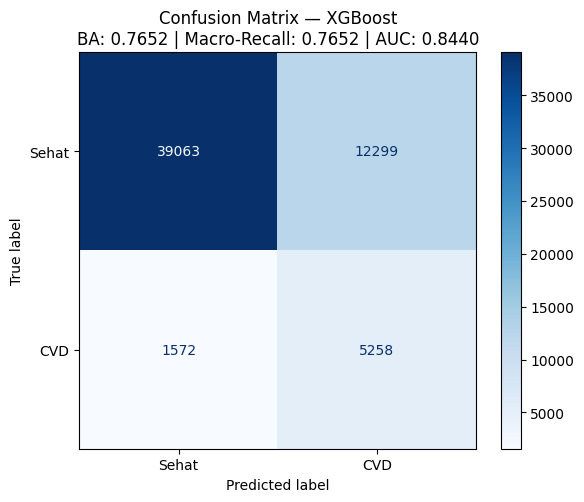

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, balanced_accuracy_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np


def train_evaluate_xgb(X_train, X_test, y_train, y_test,
                        n_estimators=300, max_depth=6, learning_rate=0.1,
                        label_names=('Sehat', 'CVD')):
    """
    Train XGBClassifier dan evaluasi lengkap dengan performance measures.

    Parameters
    ----------
    X_train, X_test : array-like  — fitur train/test
    y_train, y_test : array-like  — label train/test (binary 0/1)
    n_estimators    : int         — jumlah pohon (default 100)
    max_depth       : int         — kedalaman pohon (default 6)
    learning_rate   : float       — learning rate (default 0.1)
    label_names     : tuple       — nama kelas (default: Sehat, CVD)

    Returns
    -------
    dict berisi model dan semua metric
    """

    # ── 1. CLASS IMBALANCE ────────────────────────────────────────────────────
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"Class distribution → {label_names[0]}: {(y_train==0).sum()}, "
          f"{label_names[1]}: {(y_train==1).sum()}")
    print(f"scale_pos_weight   : {scale_pos_weight:.4f}\n")

    # ── 2. TRAINING ───────────────────────────────────────────────────────────
    model = XGBClassifier(
        n_estimators     = n_estimators,
        max_depth        = max_depth,
        learning_rate    = learning_rate,
        scale_pos_weight = scale_pos_weight,
        eval_metric      = 'logloss',
        random_state     = 42
    )
    model.fit(X_train, y_train)

    # ── 3. PREDIKSI ───────────────────────────────────────────────────────────
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # ── 4. METRICS ────────────────────────────────────────────────────────────
    balanced_acc    = balanced_accuracy_score(y_test, y_pred)
    macro_recall    = recall_score(y_test, y_pred, average='macro')
    auc_roc         = roc_auc_score(y_test, y_prob)
    f1_macro        = f1_score(y_test, y_pred, average='macro')
    f1_weighted     = f1_score(y_test, y_pred, average='weighted')
    f1_positive     = f1_score(y_test, y_pred, pos_label=1)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    sensitivity     = recall_per_class[1]
    specificity     = recall_per_class[0]

    # ── 5. PRINT HASIL ────────────────────────────────────────────────────────
    print("="*55)
    print("     PERFORMANCE MEASURES (Binary Classification)")
    print("="*55)
    print(f"  Balanced Accuracy  : {balanced_acc:.4f}  ← METRIC UTAMA")
    print(f"  Macro-Recall       : {macro_recall:.4f}  ← METRIC UTAMA")
    print(f"  AUC-ROC            : {auc_roc:.4f}")
    print("-"*55)
    print(f"  F1-Score Macro     : {f1_macro:.4f}")
    print(f"  F1-Score Weighted  : {f1_weighted:.4f}")
    print(f"  F1-Score {label_names[1]:<8}  : {f1_positive:.4f}")
    print("-"*55)
    print(f"  Sensitivity ({label_names[1]:<5}) : {sensitivity:.4f}")
    print(f"  Specificity ({label_names[0]:<5}) : {specificity:.4f}")
    print("="*55)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  TP: {tp} | TN: {tn} | FP: {fp} ← False Alarm | FN: {fn} ← Berbahaya!")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=[f'{label_names[0]} (0)', f'{label_names[1]} (1)']))

    # ── 6. PLOT CONFUSION MATRIX ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=list(label_names)).plot(cmap='Blues', ax=ax)
    ax.set_title(f"Confusion Matrix — XGBoost\n"
                 f"BA: {balanced_acc:.4f} | Macro-Recall: {macro_recall:.4f} | AUC: {auc_roc:.4f}")
    plt.tight_layout()
    plt.show()

    # ── 7. RETURN ─────────────────────────────────────────────────────────────
    return {
        'model'           : model,
        'balanced_accuracy': balanced_acc,
        'macro_recall'    : macro_recall,
        'auc_roc'         : auc_roc,
        'f1_macro'        : f1_macro,
        'f1_weighted'     : f1_weighted,
        'f1_positive'     : f1_positive,
        'sensitivity'     : sensitivity,
        'specificity'     : specificity,
        'confusion_matrix': cm,
        'y_pred'          : y_pred,
        'y_prob'          : y_prob,
    }


# ── CARA PAKAI ────────────────────────────────────────────────────────────────
results = train_evaluate_xgb(X_train, X_test, y_train, y_test)

# Akses metric atau model jika perlu
# results['model']
# results['auc_roc']

Class distribution → Sehat: 205446, CVD: 27318
scale_pos_weight   : 7.5205

     PERFORMANCE MEASURES (Binary Classification)
  Balanced Accuracy  : 0.7652  ← METRIC UTAMA
  Macro-Recall       : 0.7652  ← METRIC UTAMA
  AUC-ROC            : 0.8440
-------------------------------------------------------
  F1-Score Macro     : 0.6402
  F1-Score Weighted  : 0.8002
  F1-Score CVD       : 0.4312
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.7698
  Specificity (Sehat) : 0.7605

  TP: 5258 | TN: 39063 | FP: 12299 ← False Alarm | FN: 1572 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.96      0.76      0.85     51362
     CVD (1)       0.30      0.77      0.43      6830

    accuracy                           0.76     58192
   macro avg       0.63      0.77      0.64     58192
weighted avg       0.88      0.76      0.80     58192



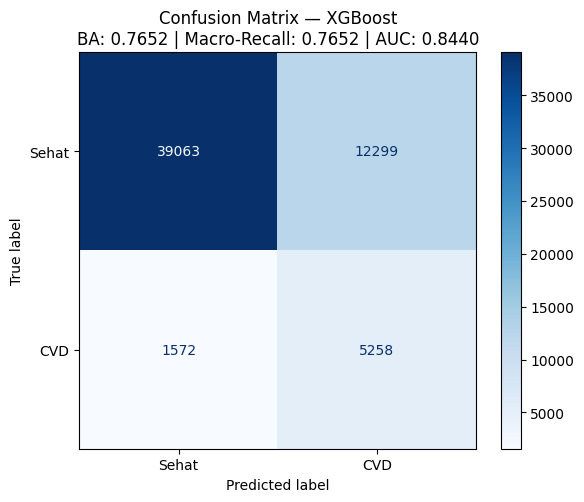

In [ ]:
# ── CARA PAKAI ────────────────────────────────────────────────────────────────
results = train_evaluate_xgb(X_train_scaled, X_test_scaled, y_train, y_test)